In [2]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("algozee/agentic-ai-security-risk-dataset")
csv_file = os.path.join(path, "agent_security_risk_scores.csv")
df = pd.read_csv(csv_file)

df.head()

100%|██████████| 28.5k/28.5k [00:00<00:00, 33.8MB/s]

Extracting files...


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
0,customer_support_agent,4,admin,read_record,file_storage_api,api_key_secret,5,0,64,0,83,0,0,1,Blocked
1,customer_support_agent,2,analyst,export_report,crm_api,sales_pipeline,3,0,66,0,65,1,2,1,Blocked
2,hr_onboarding_agent,3,vendor,change_permission,external_webhook,sales_pipeline,3,0,100,0,51,1,2,1,Blocked
3,hr_onboarding_agent,2,manager,send_email,hris_api,customer_profile,3,0,64,0,64,0,0,1,Blocked
4,finance_reconciliation_agent,1,vendor,read_record,database_api,source_code_repo,4,0,41,0,63,0,1,1,Blocked


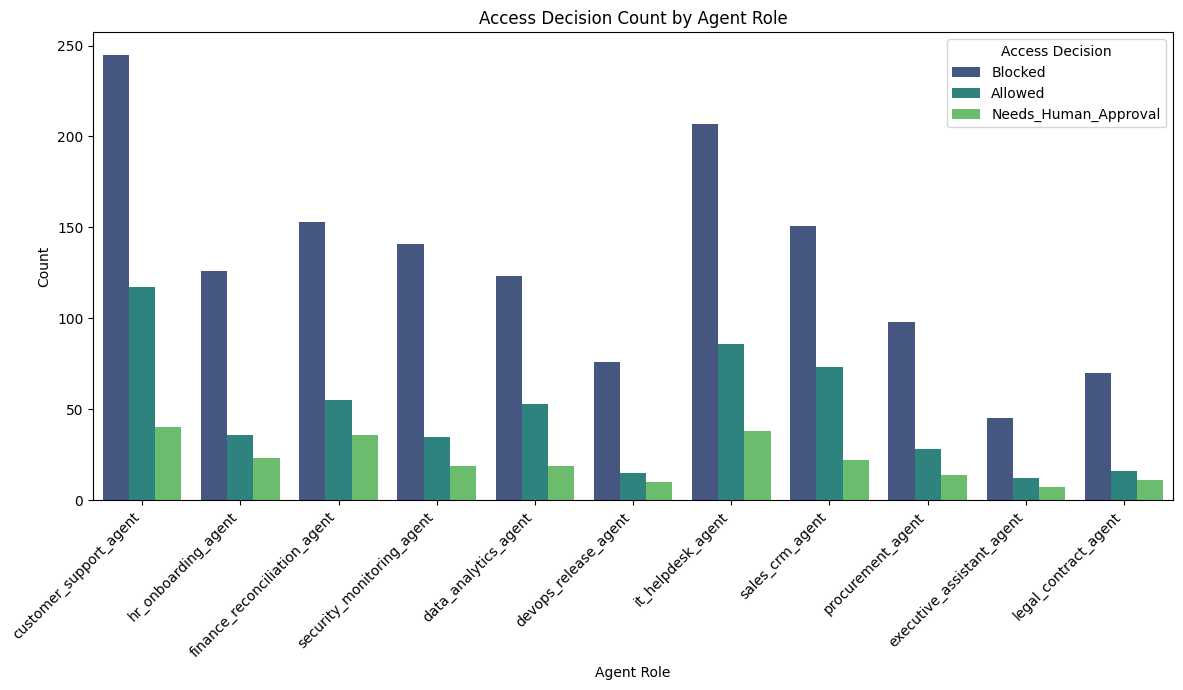

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='agent_role', hue='access_decision', palette='viridis')
plt.title('Access Decision Count by Agent Role')
plt.xlabel('Agent Role')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Access Decision')
plt.tight_layout()
plt.show()

In [4]:
pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00


In [6]:
from data_profiling import ProfileReport

def dataset_audit_report(df, title='Dataset Audit Report'):
    return ProfileReport(df, title=title)

report = dataset_audit_report(df)
report


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 46.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

This audit report helped us identify that action_risk_score is highly correlated with access_decision, which increases our confidence in answering the second part of our research question: Can we determine if an agent should be granted access to its request based on its security risk score?

Shifting attention to our primary research question, this report enabled us to identify the key features that might contribute to an agent's action_risk_score (those that are highly correlated with it). These include data_exfiltration_risk, human_approval_required, and permission_match. Our initial research question centered around predicting an agent's action_risk_score from its autonomy level, permissions, requested tools, and resource access patterns. Permission_match appears to be the only strongly correlated one at the moment, indicating that we will certainly include it as a primary feature when training our ML model.

The columns prompt_injection_detected, and audit_log_available are also highly imbalanced, so we should plan to test the accuracy of our model with and without those columns. Otherwise, our dataset has no strong outliers or missing values that require cleaning.

In [7]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


In [8]:
df.shape
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   agent_role                 2200 non-null   object
 1   agent_autonomy_level       2200 non-null   int64 
 2   user_role                  2200 non-null   object
 3   requested_action           2200 non-null   object
 4   tool_requested             2200 non-null   object
 5   resource_type              2200 non-null   object
 6   resource_sensitivity       2200 non-null   int64 
 7   permission_match           2200 non-null   int64 
 8   action_risk_score          2200 non-null   int64 
 9   prompt_injection_detected  2200 non-null   int64 
 10  data_exfiltration_risk     2200 non-null   int64 
 11  human_approval_required    2200 non-null   int64 
 12  previous_failed_attempts   2200 non-null   int64 
 13  audit_log_available        2200 non-null   int64 
 14  access_d

,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
count,2200,2200.000000,2200,2200,2200,2200,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200
unique,11,NaN,9,13,12,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,customer_support_agent,NaN,employee,read_record,database_api,customer_profile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blocked
freq,402,NaN,566,463,338,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1435
mean,NaN,3.114091,NaN,NaN,NaN,NaN,3.121818,0.392273,54.819545,0.055909,55.661818,0.420909,0.983182,0.921364,NaN
std,NaN,1.088692,NaN,NaN,NaN,NaN,1.195214,0.488368,27.931910,0.229798,20.771701,0.493817,1.474411,0.269232,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,35.000000,0.000000,40.000000,0.000000,0.000000,1.000000,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,3.000000,0.000000,54.000000,0.000000,55.000000,0.000000,0.000000,1.000000,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,4.000000,1.000000,76.000000,0.000000,69.000000,1.000000,2.000000,1.000000,NaN


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].value_counts())
    print("-"*40)

agent_role
agent_role
customer_support_agent          402
it_helpdesk_agent               331
sales_crm_agent                 246
finance_reconciliation_agent    244
data_analytics_agent            195
security_monitoring_agent       195
hr_onboarding_agent             185
procurement_agent               140
devops_release_agent            101
legal_contract_agent             97
executive_assistant_agent        64
Name: count, dtype: int64
----------------------------------------
agent_autonomy_level
agent_autonomy_level
3    786
4    596
2    411
5    220
1    187
Name: count, dtype: int64
----------------------------------------
user_role
user_role
employee           566
analyst            392
manager            316
contractor         211
service_account    187
admin              152
vendor             142
security_admin     118
guest              116
Name: count, dtype: int64
----------------------------------------
requested_action
requested_action
read_record          463
search_r

The above column count analysis reveals that agent_role, agent_autonomy_level, user_role, requested_action, tool_requested, resource_type, resource_sensitivity, permission_match, action_risk_score, data_exfiltration_risk and previous_failed_attempts have some imbalances between categories/bins along with the prompt_injection_detected and audit_log_available columns that ydata-profiling revealed as being heavily imbalanced.
While this is normal in many datasets, we might utilize scikit-learn's train_test_split's stratify feature to handle this slight imbalance. We might also use Precision, Recall, the F1-score, or the ROC-AUC curve as evaluation metrics instead of accuracy, since accuracy will not correctly evaluate the model if the data behind it is imbalanced.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'customer_support_agent'),
  Text(1, 0, 'hr_onboarding_agent'),
  Text(2, 0, 'finance_reconciliation_agent'),
  Text(3, 0, 'security_monitoring_agent'),
  Text(4, 0, 'data_analytics_agent'),
  Text(5, 0, 'devops_release_agent'),
  Text(6, 0, 'it_helpdesk_agent'),
  Text(7, 0, 'sales_crm_agent'),
  Text(8, 0, 'procurement_agent'),
  Text(9, 0, 'executive_assistant_agent'),
  Text(10, 0, 'legal_contract_agent')])

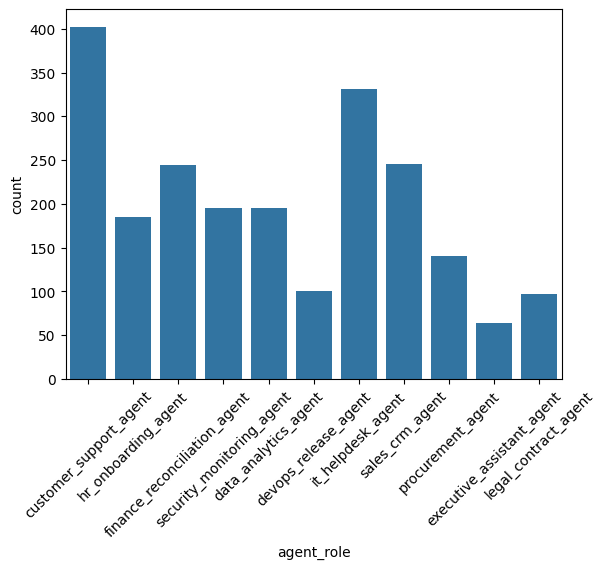

In [ ]:
sns.countplot(data=df, x='agent_role')
plt.xticks(rotation=45)

<Axes: xlabel='access_decision', ylabel='count'>

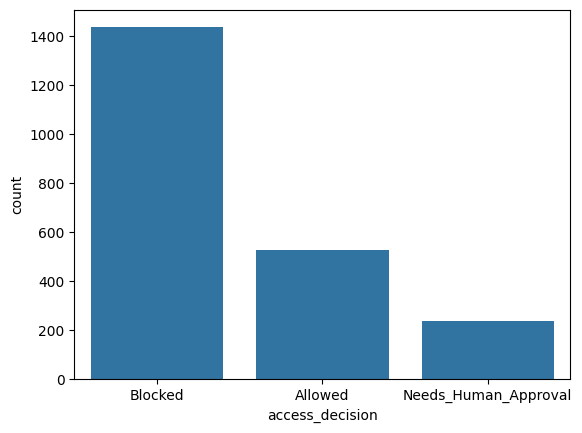

In [ ]:
sns.countplot(data=df, x='access_decision')

Since access_decision is one of our most important predicted columns, we may want to structure our train_test_split in such a way that there is a more equal balance of blocked, allowed, and needs_human_approval categories. Else, our model will tend to output a blocked decision for most inputs.

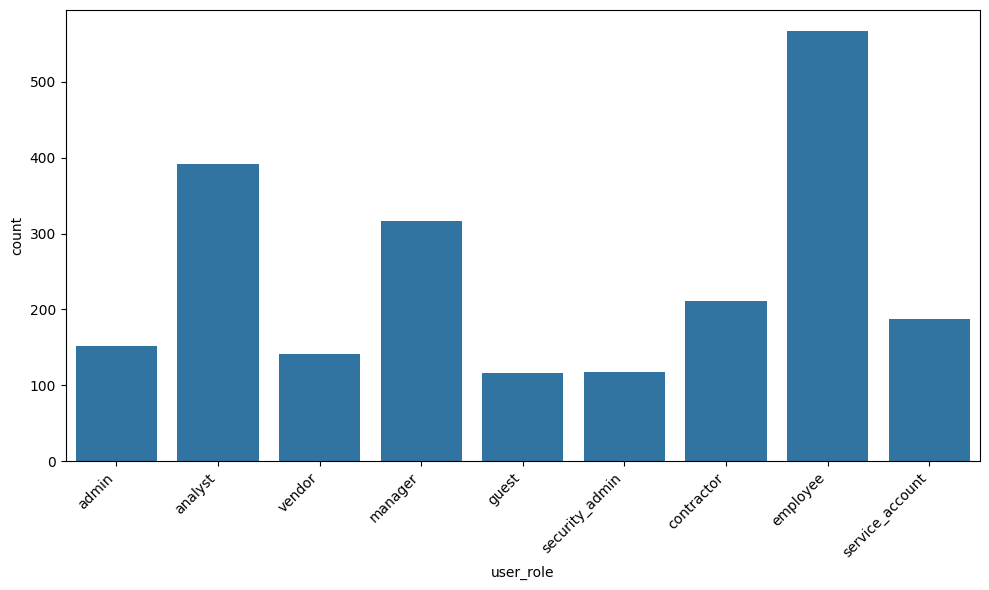

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='user_role')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Of all requests made by each agent, what percentage were allowed, blocked, or required human approval?
pd.crosstab(
    df['agent_role'],
    df['access_decision'],
    normalize='index'
)

access_decision,Allowed,Blocked,Needs_Human_Approval
agent_role,,,
customer_support_agent,0.291045,0.609453,0.099502
data_analytics_agent,0.271795,0.630769,0.097436
devops_release_agent,0.148515,0.752475,0.099010
executive_assistant_agent,0.187500,0.703125,0.109375
finance_reconciliation_agent,0.225410,0.627049,0.147541
hr_onboarding_agent,0.194595,0.681081,0.124324
it_helpdesk_agent,0.259819,0.625378,0.114804
legal_contract_agent,0.164948,0.721649,0.113402
procurement_agent,0.200000,0.700000,0.100000


All the agent_role categories appear to have similar distributions of access_decisions, which indicates that the imbalance in agent_role is not much of an issue and will not affect access_decision much. That is to say, most agents will receive an access_decision of blocked regardless of their role.

In [ ]:
pd.crosstab(
    df['user_role'],
    df['access_decision'],
    normalize='index'
)

access_decision,Allowed,Blocked,Needs_Human_Approval
user_role,,,
admin,0.322368,0.552632,0.125000
analyst,0.244898,0.668367,0.086735
contractor,0.222749,0.691943,0.085308
employee,0.166078,0.752650,0.081272
guest,0.189655,0.724138,0.086207
manager,0.325949,0.515823,0.158228
security_admin,0.381356,0.449153,0.169492
service_account,0.294118,0.534759,0.171123
vendor,0.105634,0.823944,0.070423


However, it appears this is not the case with user_role, which has different distributions of access_decisions depending on the role. Perhaps user_role would be a better column to base predictions of access_decision on, since it has a visible impact on it compared to agent_role.

In [9]:
df.groupby('access_decision')['action_risk_score'].mean()

,action_risk_score
access_decision,
Allowed,23.994297
Blocked,66.221603
Needs_Human_Approval,54.200837


This further demonstrates the strong correlation between access_decision and action_risk_score, and increases confidence in our second research question.

<Axes: xlabel='requested_action', ylabel='user_role'>

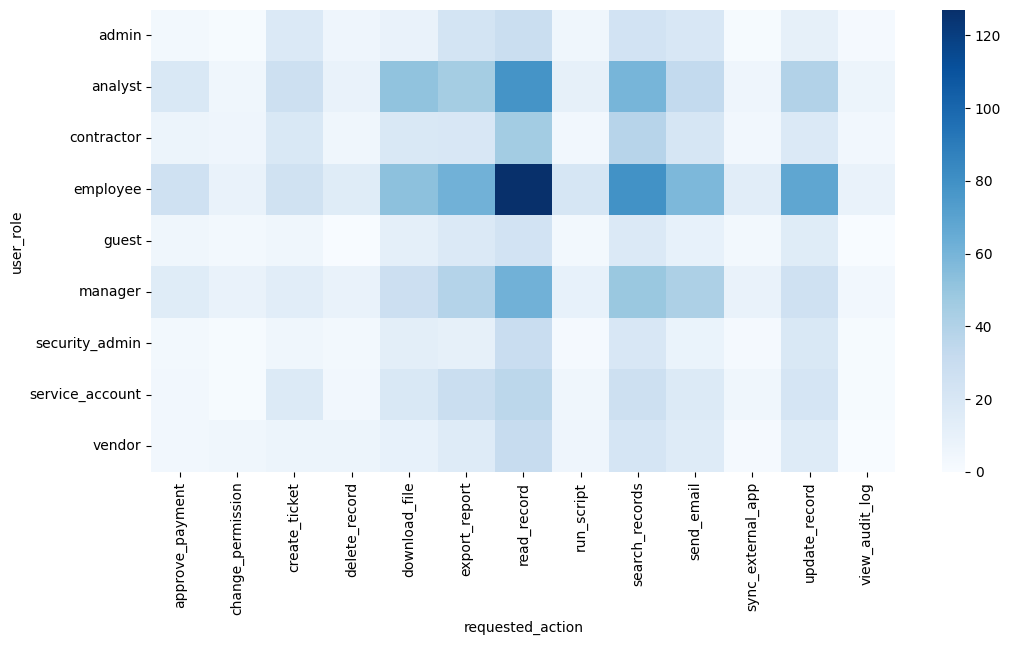

In [ ]:
# Which user roles perform which actions most frequently
table = pd.crosstab(
    df['user_role'],
    df['requested_action']
)

plt.figure(figsize=(12,6))
sns.heatmap(table, cmap='Blues')

In [12]:
# Does the history of failed attempts influence access decisions
df.groupby('access_decision')['previous_failed_attempts'].mean()

,previous_failed_attempts
access_decision,
Allowed,0.627376
Blocked,1.166551
Needs_Human_Approval,0.665272


In [13]:
df.groupby('access_decision')['agent_autonomy_level'].mean()

,agent_autonomy_level
access_decision,
Allowed,3.041825
Blocked,3.137282
Needs_Human_Approval,3.133891


Previous_failed_attempts might be a more suitable column to predict access_decisions than agent_autonomy_level, especially since agent_autonomy_level is not typically an objective data point you can collect about an agent, and it is not strongly correlated with access_decision.

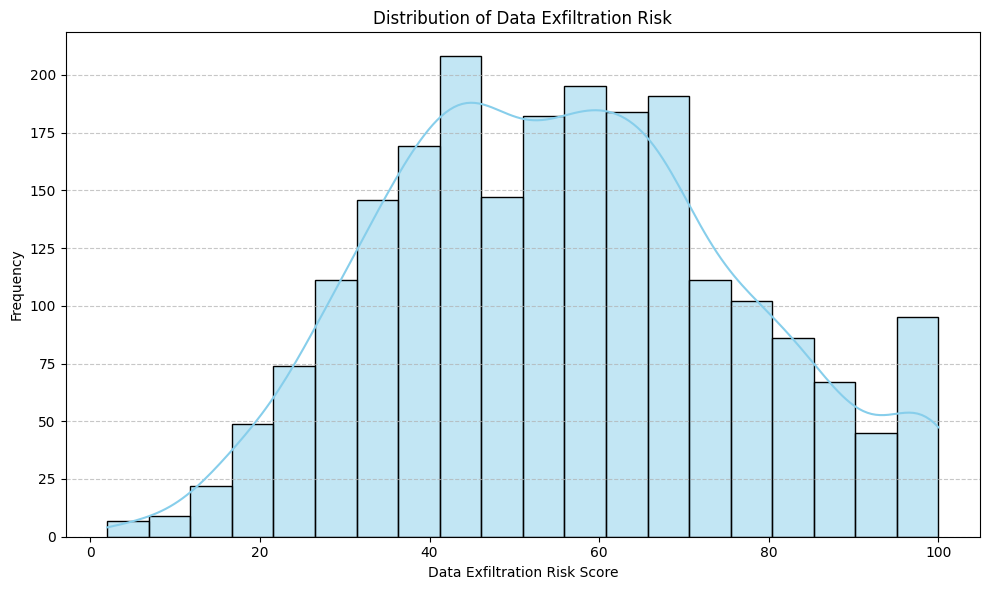

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['data_exfiltration_risk'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Data Exfiltration Risk')
plt.xlabel('Data Exfiltration Risk Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

data_exfiltration_risk is evenly distributed without any outliers, and is a good feature to predict access_decision and action_risk_score.

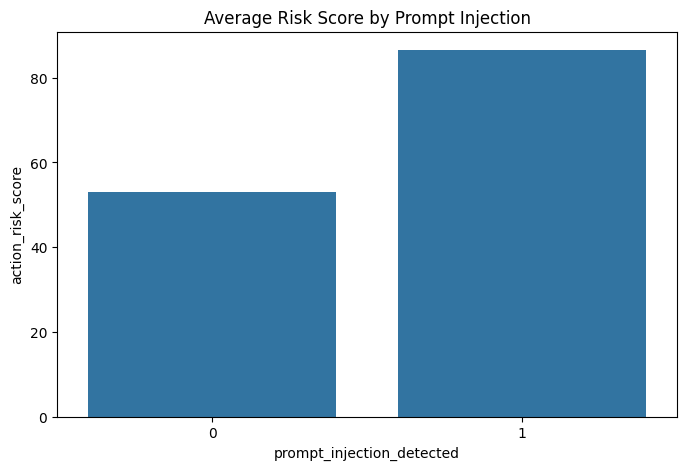

In [17]:
# testing impact of prompt_injection_detected on action_risk_score

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='prompt_injection_detected', y='action_risk_score', errorbar=None)
plt.title('Average Risk Score by Prompt Injection')
plt.show()

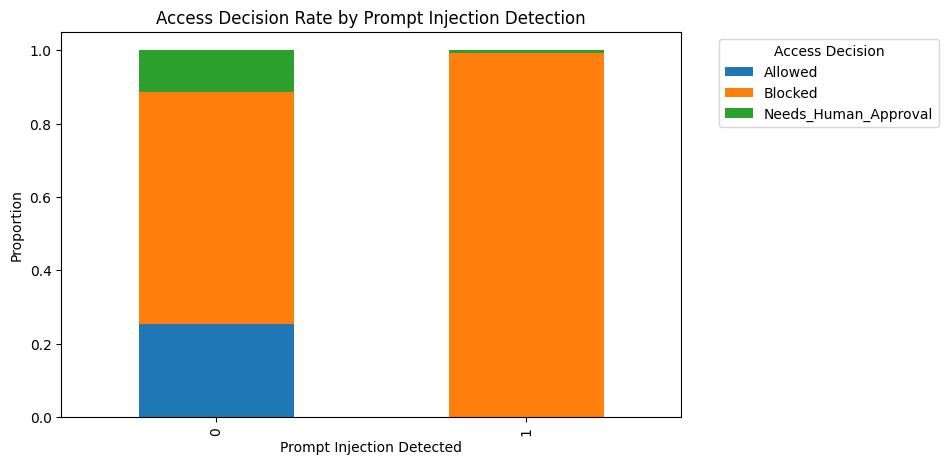

In [20]:
ct = pd.crosstab(
    df['prompt_injection_detected'],
    df['access_decision'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('Prompt Injection Detected')
plt.ylabel('Proportion')
plt.title('Access Decision Rate by Prompt Injection Detection')
plt.legend(title='Access Decision', bbox_to_anchor=(1.05, 1))
plt.show()

In [23]:
df[(df['prompt_injection_detected'] == 1) & (df['access_decision'] != 'Blocked')]


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
654,sales_crm_agent,2,contractor,send_email,email_api,customer_profile,3,1,49,1,81,0,0,1,Needs_Human_Approval


Since prompt_injection_detected has a much stronger concentration of 0 (no) values than 1 (yes) values, the concern is that the model might overfit to the access_decision values for the rows in the dataset that have prompt_injection_detected values of 1.

However, the stacked bar chart above reveals that rows with prompt_injection_detected values of 1 are actually extremely consistent in terms of their access_decision values. The other concern is that prompt_injection_detected might not be predicting access_decision but rather revealing it, meaning there's a hard-coded rule that sets the access_decision to Blocked if a prompt injection is detected. Since there's only one row where a prompt injection is detected but the access_decision is needs human approval, our model may base its predictions entirely on the prompt_injection_detected column, so we should remove it from our dataset.

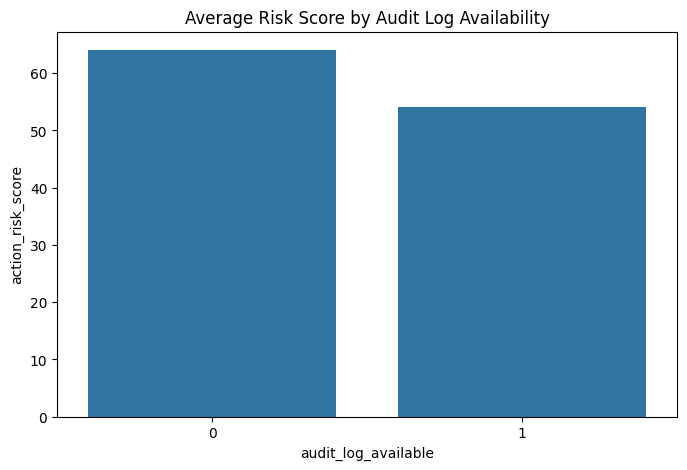

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='audit_log_available', y='action_risk_score', errorbar=None)
plt.title('Average Risk Score by Audit Log Availability')
plt.show()

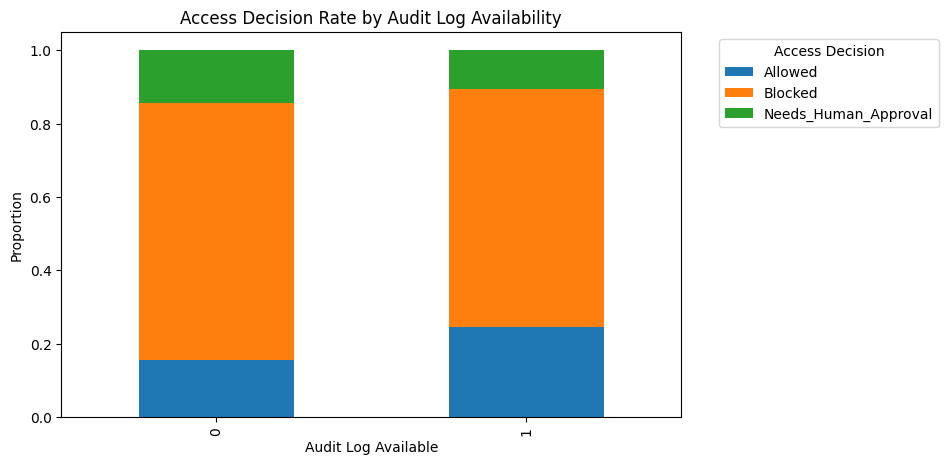

In [25]:
ct = pd.crosstab(
    df['audit_log_available'],
    df['access_decision'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.xlabel('Audit Log Available')
plt.ylabel('Proportion')
plt.title('Access Decision Rate by Audit Log Availability')
plt.legend(title='Access Decision', bbox_to_anchor=(1.05, 1))
plt.show()

Since audit_log_availability doesn't appear to impact access_decision or action_risk_score, we should aim to run tests to determine if it introduces unecessary noise or may actually be beneficial for the model to predict access_decision/action_risk_score

# **Findings From Analysis**

### Data Cleaning
-  prompt_injection_detected should be removed from the dataset before training, as it is heavily skewed with a 95 - 5 split between no (0) and yes (1) values. All yes (1) values correspond to an access_decision of blocked, which could cause the model to overfit on those rows and categorize future ones as blocked solely based on prompt_injection_detected rather than other features.
- When creating the train_test_split using scikit-learn, utilize a stratified or balanced split to account for slight imbalances in the other columns.
- During model evaluation, refrain from using accuracy as a measure of model performance, as it is a poor indicator when the dataset is imbalanced. Opt to use Precision, Recall, the F1-score, or the ROC-AUC curve instead.

### Research Question
- Our initial research question(s): Can we predict the security risk score of an AI agent's action based on its autonomy level, permissions, requested tools, and resource access patterns? Can we determine if an agent should be granted access to its request based on its security risk score?
- Our analysis has revealed that action_risk_score and access_decision are strongly correlated, so our confidence in our second question (Can we determine if an agent should be granted access to its request based on its security risk score?) is high.
- Graphing and analyzing the relationships between columns in the dataset and access_decision/action_risk_score have depicted that there are many other features that strongly correlate with access_decision/action_risk_score than the ones in our research question. Rather than focusing solely on autonomy level, permissions, requested tools, and resource access patterns, we should include all features and focus on the strongest correlated features: data_exfiltration_risk, human_approval_required, and permission_match.